# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd # importar librerías
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum())
print()
print("Proporción de valores nulos")
print(users.isna().mean())

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos")
print(usage.isna().sum())
print()
print("Proporción de valores nulos")
print(usage.isna().mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
¿Qué columnas tienen valores faltantes y en qué proporción?
  
  El datasets users presenta valores faltantes en las columnas:
  - "city" con 469 nulos que corresponden al 11,72%
  - "churn_date" con 3534 nulos que corresponden al 88,35%
  
  El dataset usage presenta valores faltantes en las columnas:
  - "duration" con 22076 nulos que corresponden al 55,19%
  - "length" con 17896 nulos que corresponden al 44,74%

Indica qué harías: ¿imputar, eliminar, ignorar?

  - Para los valores faltantes en la columna "city" (11,72%) se decidió conservar los valores nulos, ya que su ausencia no afecta las conclusiones del estudio ni compromete la calidad de los resultados obtenidos.
  - Los valores faltantes en la columna "churn_date" están asociados a los clientes que permanecian activos; no poseen una fecha de cancelación registrada. En este caso, lo nulos tienen un significado real dentro del contexto del negocio; no son errores ni datos faltantes que deban corregirse, por lo tanto los conservamos como nulos.
  - Los valores faltantes en las columnas duration y length corresponden principalmente a faltantes estructurales derivados del tipo de interacción registrada en la columna type (call o text), por lo que fueron conservados como nulos al no representar errores ni pérdidas de información. Sin embargo, al comparar la cantidad de valores nulos en ambas variables, se observó que su suma no coincide exactamente con el total de registros del dataset: 22.076 + 17.896 = 39.972, mientras que la tabla contiene 40.000 observaciones. Esta diferencia de 28 registros (0,07% del total) sugiere la existencia de algunos casos que no siguen esta regla y que podrían corresponder a valores faltantes reales, el porcentaje de esos casos es muy bajo por lo tanto esos también se dejarán como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id no muestra valores inválidos ni anomalías aparentes.
- La columna age muestra edad minima de -999, no existe tal edad; es un sentinel utilizado para representar datos faltantes o desconocidos.

In [13]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id no presentan valores inválidos aparentes.
- La columna duration presenta valores entre 0 y 120 minutos. No se identifican sentinels evidentes; sin embargo, el valor mínimo de 0 podría corresponder a llamadas canceladas o no completadas.
- La columna length presenta valores entre 0 y 1490 caracteres. No se observan sentinels evidentes. De manera similar, los valores de 0 podrían representar mensajes vacíos o requerir validación adicional para determinar si son válidos.

In [14]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()

city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` contiene seis categorías de ciudades con inconsistencia en el formato (Bogotá, CDMX, Medellín, GDL, Cali y MTY). Además de los 469 valores nulos (11,72%) ya identificados, se encontró la categoría "?" con 96 registros, la cual podría corresponder a un sentinel utilizado para representar información desconocida o no registrada.
- La columna `plan` únicamente presenta dos categorías (Basico y Premium), las cuales son consistentes con los planes ofrecidos por la compañía. No se observan valores inválidos ni categorías inesperadas y validamos que la columna está completa por la suma de los valores únicos de cada categoría, además el plan basico corresponde al 64,88% de los usuarios y el plan premium corresponde al 35,12% de los usuarios.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no presenta sentinelas y está completa, esto lo confirmamos una vez más al sumar los valores únicos de cada categoría; el resultado coincide con la cantidad de filas del dataframe usage.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Respuestas**
- En age se identificó el valor -999, considerado un sentinel. Acción: reemplazarlo por NaN.
- En city se encontró la categoría ?, que podría representar información desconocida. Acción: reemplazarla por NaN.
- Las columnas user_id, id, plan y type no mostraron valores inválidos o sentinels. Acción: no realizar modificaciones.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se identificaron registros correspondientes a los años 2022, 2023 y 2024, que se encuentran dentro del rango esperado. Sin embargo, también se detectaron 40 registros del año 2026, siendo fechas imposibles.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros corresponden al año 2024, por lo que no se identificaron fechas fuera del rango esperado. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Respuesta**

Se detectaron 40 fechas fuera de rango en la columna reg_date, correspondientes al año 2026. Dado que el conjunto de datos contiene información registrada hasta 2024, estos valores podrían deberse a errores de captura o digitación. Se recomienda reemplazarlos por valores nulos (NaN) o excluirlos del análisis que dependa de esta variable. Por otro lado, la columna date no presentó inconsistencias, ya que todos sus registros pertenecen al año 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)

age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

- Estos nulos en "duración" y "length" son MAR, dependen principalmente del tipo de interacción en la columna "type" ya que cuando es call no hay nulos en "duración" pero si en "length" y cuando es text no hay nulos en "length" pero si en duración. Esto tiene sentido ya que el texto se mide en logitud(caracteres) y llamada se mide en duración(tiempo)

- Sin embargo existen 28 casos (0,07%) que no siguen este patrón, ya que 40.000 − (22.076 + 17.896) = 28 registros, lo que sugiere que esos si pueden ser inconsistencias o faltantes reales.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

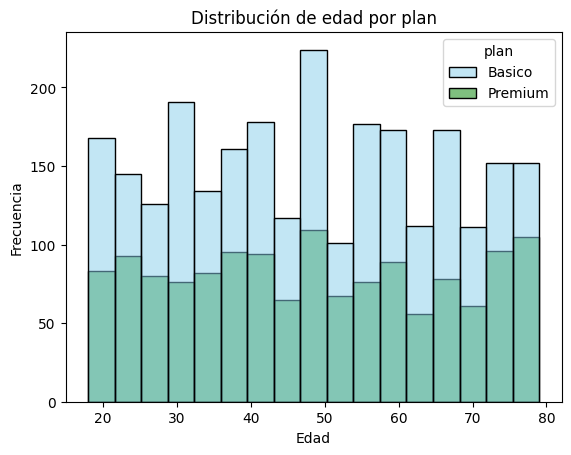

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- En todas las edades es mayor la frecuencia de personas en el plan básico que en el plan premium, esto se debe a que el plan basico corresponde al 64,88% de los usuarios y el plan premium corresponde al 35,12% de los usuarios según calculamos anteriormente.
- No se observa un grupo de edad predominante asociado a un plan específico.
- La distribución puede considerarse aproximadamente normal, sin un sesgo evidente hacia edades más jóvenes o mayores.

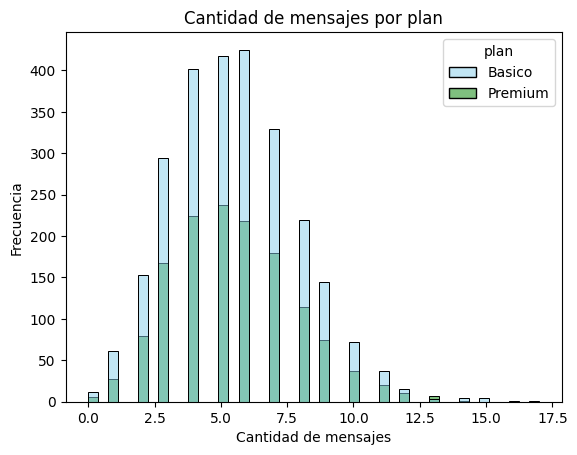

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es sesgada a la derecha, ya que pocos usuarios envían cantidades muy altas de mensajes.
- La mayoría de usuarios de ambos planes muestran patrones de envío de mensajes similares, concentrándose principalmente entre 3 y 7 mensajes.
- No hay una evidencia muy clara de relación entre el plan y la cantidad de mensajes que envian.

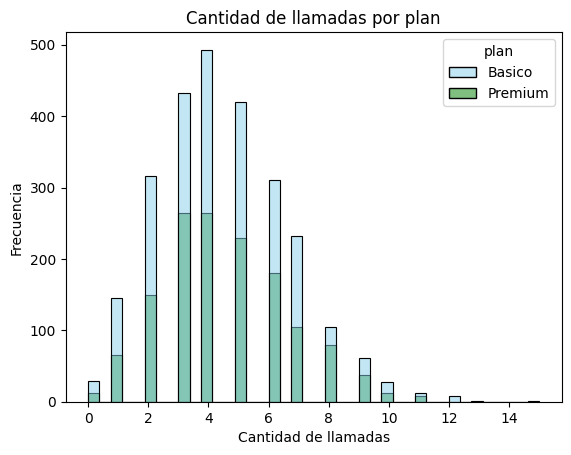

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es sesgada a la derecha, debido a la presencia de algunos usuarios con un número elevado de llamadas.
- La mayor parte de los usuarios realiza entre 2 y 6 llamadas, independientemente del plan contratado.
- No se evidencian clara de relación entre cantidad de llamadas y plan.

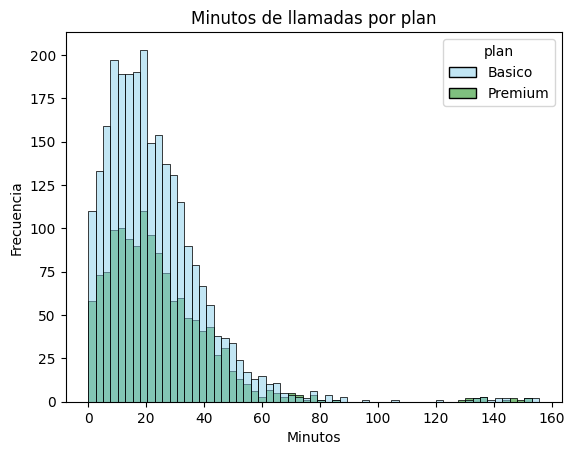

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Minutos de llamadas por plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayoría de los usuarios acumula pocos minutos de llamadas, concentrándose aproximadamente entre 5 y 35 minutos.
- Se observa una cola larga hacia la derecha, indicando la existencia de usuarios con consumos excepcionalmente altos (algunos superiores a 100 minutos).
- Esto sugiere la presencia de posibles valores extremos (outliers). El patrón general es similar entre ambos planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

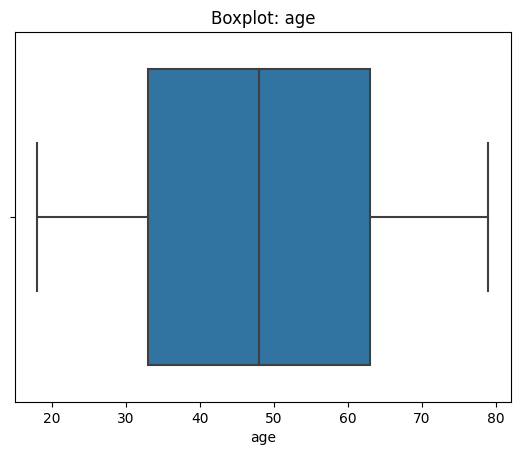

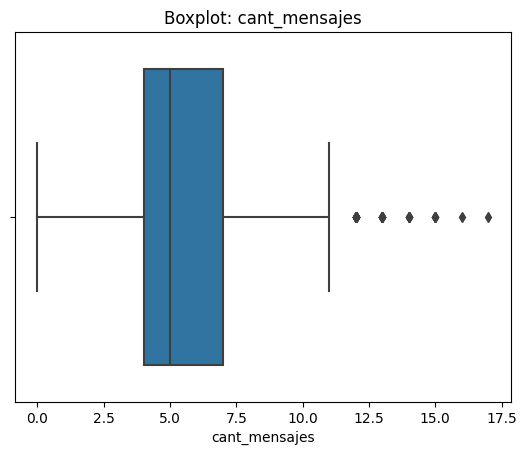

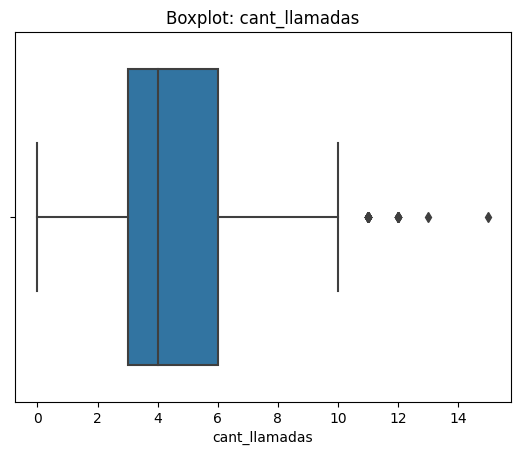

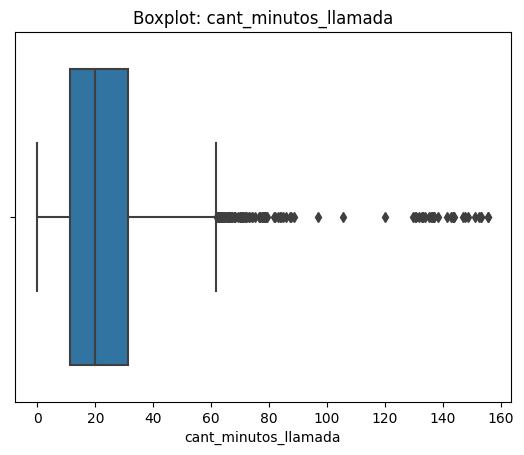

In [34]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No se esperan outliers, ya que la edad está acotada entre valores plausibles para los usuarios.
- cant_mensajes: Se observan algunos valores altos que podrían clasificarse como outliers según el criterio estadístico, aunque pueden corresponder a usuarios con un uso intensivo legítimo.
- cant_llamadas: Existen algunos valores extremos hacia la derecha, asociados a usuarios que realizan muchas más llamadas que la mayoría.
- cant_minutos_llamada: Presenta la mayor cantidad de valores extremos, con usuarios que acumulan muchos más minutos de llamadas que el resto de la población.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'\n{col}')
    print('Límite superior:', limite_superior)
    print('Máximo observado:', user_profile[col].max())


cant_mensajes
Límite superior: 11.5
Máximo observado: 17.0

cant_llamadas
Límite superior: 10.5
Máximo observado: 15.0

cant_minutos_llamada
Límite superior: 61.8575
Máximo observado: 155.69


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡**Insights:**
- **cant_mensajes: mantener o no outliers, porqué?** Se identificaron valores por encima del límite superior del método IQR (11,5 mensajes), alcanzando un máximo de 17 mensajes. Sin embargo, la diferencia no es extrema y estos casos pueden representar usuarios con un uso más intensivo del servicio. Por lo tanto, se decidió conservar los outliers, ya que no existen indicios de errores en los datos.
- **cant_llamadas: mantener o no outliers, porqué?** Se observaron valores superiores al límite establecido (10,5 llamadas), con un máximo de 15 llamadas. Por el contexto estos registros podrían corresponder a clientes con alta frecuencia de uso, se optó por mantener los outliers.
- **cant_minutos_llamada: mantener o no outliers, porqué?** Esta variable presenta los valores extremos más pronunciados, con un límite superior de 61,86 minutos y un máximo de 155,69 minutos. Aunque estos usuarios se alejan considerablemente del comportamiento típico, se decidió conservarlos, ya que también según el contexto pueden representar clientes con un consumo elevado real y su eliminación podría sesgar el análisis del comportamiento de uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def clasificar_uso(row):

    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'


user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def clasificar_edad(row):

    if row['age'] < 30:
        return 'Joven'

    elif row['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'


user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

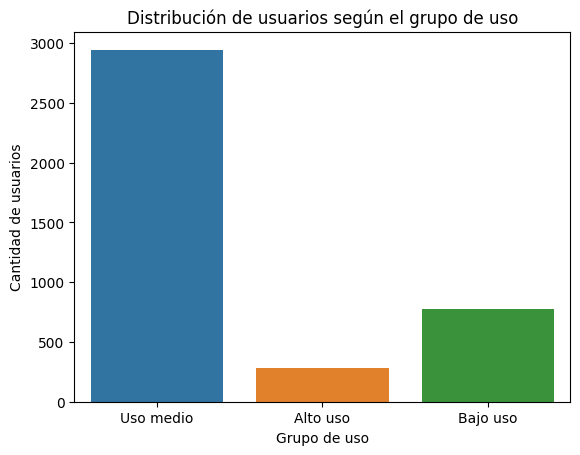

In [44]:
# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso')

plt.title('Distribución de usuarios según el grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

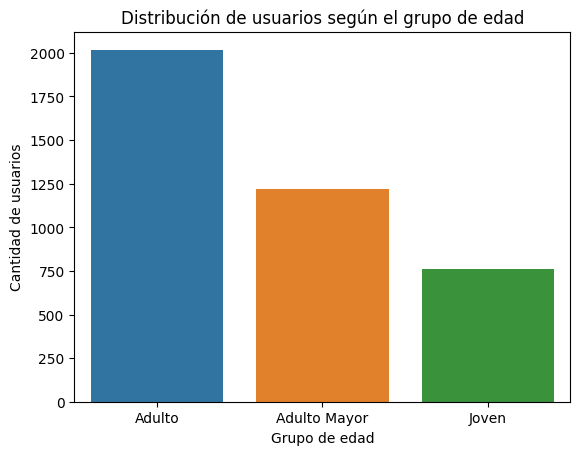

In [43]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios según el grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

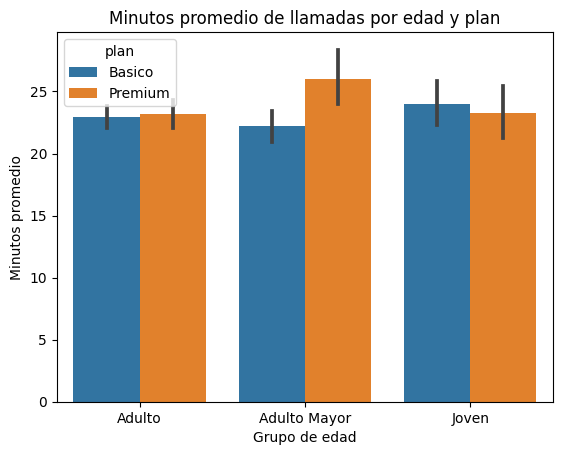

In [149]:
sns.barplot(
    data=user_profile,
    x='grupo_edad',
    y='cant_minutos_llamada',
    hue='plan'
)

plt.title('Minutos promedio de llamadas por edad y plan')
plt.xlabel('Grupo de edad')
plt.ylabel('Minutos promedio')
plt.show()

In [55]:
(
    user_profile.groupby('grupo_edad')['cant_minutos_llamada']
    .sum()
    .div(user_profile['cant_minutos_llamada'].sum())
    .mul(100)
    .round(2)
)

grupo_edad
Adulto          49.74
Adulto Mayor    30.90
Joven           19.36
Name: cant_minutos_llamada, dtype: float64

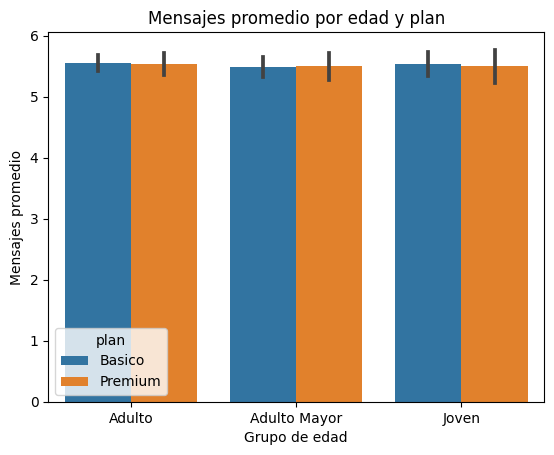

In [150]:
sns.barplot(
    data=user_profile,
    x='grupo_edad',
    y='cant_mensajes',
    hue='plan'
)

plt.title('Mensajes promedio por edad y plan')
plt.xlabel('Grupo de edad')
plt.ylabel('Mensajes promedio')
plt.show()

In [54]:
(
    user_profile.groupby('grupo_edad')['cant_mensajes']
    .sum()
    .div(user_profile['cant_mensajes'].sum())
    .mul(100)
    .round(2)
)

grupo_edad
Adulto          50.66
Adulto Mayor    30.35
Joven           19.00
Name: cant_mensajes, dtype: float64

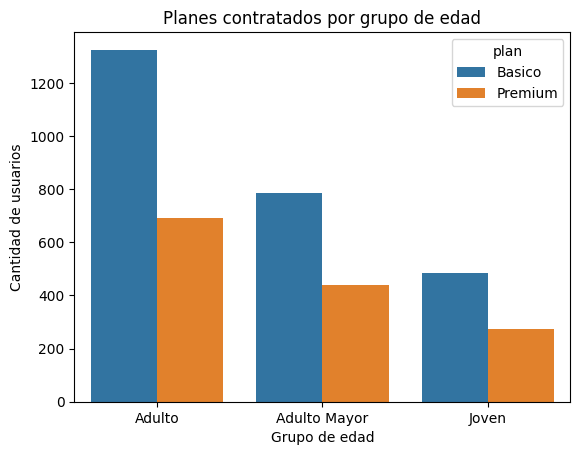

In [153]:
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='plan'
)

plt.title('Planes contratados por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [45]:

pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['plan'],
    normalize='index'
) * 100


plan,Basico,Premium
grupo_edad,,
Adulto,65.659068,34.340932
Adulto Mayor,64.157119,35.842881
Joven,63.947368,36.052632



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificó un valor sentinel en la variable age (-999), utilizado para representar edades desconocidas. Este valor fue reemplazado por la mediana de la distribución para evitar distorsionar el análisis.
- La columna city presentó 469 valores faltantes (11,72%) y 96 registros con el valor "?". Los valores ausentes se conservaron como nulos y se reemplazó "?" por NaN.
- En churn_date, el 88,35% de los registros estaban vacíos. Se determinó que estos nulos correspondían a clientes activos que no habían cancelado el servicio, por lo que fueron conservados al representar información válida del negocio.
- Las columnas duration y length presentaron valores faltantes estructurales asociados al tipo de interacción (call o text). Aunque la mayoría de estos nulos obedecían a esta lógica, se detectaron 28 registros adicionales que no seguían el patrón esperado pero que equivalen al 0,07%.
- Se identificaron 40 fechas de registro correspondientes al año 2026, fuera del rango esperado (hasta 2024), las cuales fueron marcadas como valores nulos.


🔍 **Segmentos por Edad**
- Adulto representa un 50.45% de los usuarios totales, el adulto mayor representa un 30.55% de los usuarios totales y el joven representa un 19.00% de los usuarios totales (El adulto representa el mayor porcentajes de los usuarios totales).
- La distribución de los planes contratados es bastante similar entre los distintos grupos de edad. Adulto (65.65% plan básico, 34.34% plan premium), Adulto mayor (64.15% plan básico, 35.84% plan premium) y Joven (63.94% plan básico	36.05% plan premium). Aunque las diferencias son mínimas, se observa que los adultos presentan la mayor proporción de usuarios de ese grupo en el plan Básico, mientras que los jóvenes registran la mayor participación relativa del plan Premium.
- La proporción de envío de mensajes tanto en plan premium y básico es casi igual para los tres grupos de edad.
- El adulto mayor presenta la mayor cantidad de minutos promedio por llamada con el plan premium, mientras que el joven la mayor participación relativa de cantidad de minutos premedio pero en el plan básico.


📊 **Segmentos por Nivel de Uso**
- La mayor parte de los clientes se concentró en el segmento de uso medio, caracterizado por realizar menos de 10 llamadas y enviar menos de 10 mensajes.
- Los usuarios de bajo uso representaron un grupo importante que podría estar subutilizando los beneficios incluidos en sus planes.
- Los usuarios de alto uso constituyen un segmento más reducido, pero potencialmente más valioso debido a su mayor consumo de servicios.

📈 **Patrones de uso extremos**
- Las variables cantidad de mensajes, cantidad de llamadas y minutos de llamadas presentaron distribuciones sesgadas a la derecha, indicando que la mayoría de los usuarios tiene niveles moderados de consumo.
- Se identificaron valores extremos mediante el método IQR. Sin embargo, estos registros fueron conservados, ya que representan comportamientos plausibles dentro del contexto de una empresa de telecomunicaciones y no evidencian errores de captura.
- El caso más destacado fue cant_minutos_llamada, con usuarios que alcanzaron hasta 155,69 minutos, muy por encima del límite estadístico calculado. Estos clientes podrían corresponder a usuarios intensivos del servicio.

➡️ Esto sugiere que ConnectaTel
- Posee una base de clientes compuesta en mayor medida por usuarios de consumo medio y por usuarios del grupo de edad adultos.
- Existe un grupo reducido de usuarios que están en el plan básico pero aún así muestran un alto uso de los servicios, representando una oportunidad para ofrecerles el plan premium.
- Aunque el plan más contratado es el plan básico entre todos los usuarios, la usabilidad en envío de mensajes promedio y minutos promedio de llamada es casi el mismo con ambos planes para todos los grupos. 


💡 **Recomendaciones**
- Revisar la estructura de los planes actuales para asegurar una diferenciación más clara entre las ofertas Básico y Premium (o crear nuevos planes) ya que los actuales son usados en igual medida por los tres grupos de edad.
- Sugerido campaña de fidelización para los usuarios de alto uso y/o plan especial.
- Ya que la edad no es un criterio suficientemente diferenciador para segmentar la oferta comercial de ConnectaTel porque tanto el consumo de mensajes como el de llamadas se distribuyen de manera proporcional entre los grupos de edades, entonces, se sugiere explorar otras variables que pueden ser más relevantes para diseñar estrategias comerciales, como el nivel de uso (bajo, medio o alto), ciudad o  el historial de permanencia de los clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`